# Part II - Trip Duration Analysis
## by Gabriela Lopes

## Investigation Overview

>The primary goal of this investigation is to explore bike-sharing usage patterns within a specific city dataset. By analyzing trip durations, user types, and station preferences, this presentation aims to uncover key behavioral trends among users and their interactions with the bike-sharing system. The insights derived from this investigation provide valuable information for optimizing services, improving user experience, and identifying areas for strategic growth.

>Key Insights
Trip Duration Patterns:

>The majority of trips fall within a short time frame, typically under 15 minutes, indicating the popularity of bike-sharing for quick commutes.
Outliers with unusually long durations were identified and filtered to focus on typical usage.
User Type and Trip Preferences:

>Subscribers dominate the user base, with a consistent pattern of shorter trips compared to customers.
Customers exhibit more variability in trip durations, suggesting a mix of recreational and occasional usage.
Station Popularity:

>Certain stations are consistently more popular for starting trips, reflecting their accessibility and convenience for users.
The visualization of station usage highlights key hubs and areas with high demand.


## Dataset Overview and Executive Summary

>Dataset Overview:
The dataset used in this analysis contains information about individual bike-share trips, including trip durations, user types, and start and end stations. Data cleaning and preprocessing steps were performed to remove outliers, missing values, and inconsistencies, ensuring accuracy in the subsequent analyses.

>Executive Summary:
The analysis revealed several critical insights into the behavior of bike-sharing users:

>Trip Duration: Most trips are short, reflecting the system's efficiency for urban travel.
User Types: Subscribers are the primary users, with predictable and regular usage patterns, whereas customers show a wider range of trip purposes.
Popular Stations: Specific start stations experience higher demand, highlighting potential areas for resource allocation or expansion.
These findings are supported by three key visualizations:

>Trip Duration Distribution: A histogram showing the distribution of trip durations after filtering outliers.
User Type Comparison: A bar chart comparing trip durations across user types.
Station Popularity Map: A visualization highlighting the most frequented starting stations, providing insight into demand hotspots.
By focusing on these aspects, the presentation effectively communicates the main usage trends and operational insights from the dataset.








### Overall Goals of the Presentation

The main goal of this presentation is to provide a clear, concise, and visually compelling summary of the bike trip data analysis. By leveraging visualizations, we aim to highlight key insights about the patterns in bike usage, including factors like trip durations, station locations, and user behaviors. The purpose is to present the most relevant data to help inform decisions about potential improvements or optimizations in the bike-sharing system.

Key Insights:
Trip Duration Analysis: The majority of bike trips are relatively short, with most durations being under 800 seconds.
Start Station Analysis: Certain stations are more frequently used than others, with the most popular stations being concentrated in specific areas of the city.
User Type Trends: Subscribers tend to take longer trips than customers, suggesting differing behaviors and preferences.
These insights will be supported through three visualizations:

Distribution of Trip Durations: A histogram to explore the typical trip duration.
Top Start Stations: A bar chart visualizing the most popular starting stations.
Heatmap of Start and End Stations: A visualization to showcase the spatial distribution of bike stations and trip origins/destinations.

In [1]:
# import all packages and set plots to be embedded inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# suppress warnings from final output
import warnings
warnings.simplefilter("ignore")

In [2]:
!pip install nbconvert[qtpdf]
!pip install pyqtwebengine

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 227.6/227.6 kB 3.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 63.6 MB/s eta 0:00:00:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 270.8/270.8 kB 34.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.6/90.6 MB 14.3 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 MB 21.8 MB/s eta 0:00:0000:0100:01
ERROR: Could not install packages due to an OSError: [Errno 13] Permission denied: '/opt/venv/lib/python3.10/site-packages/PyQt5'
Check the permissions.


[notice] A new release of pip is available: 23.0.1 -> 24.3.1
[notice] To update, run: pip install --upgrade pip
  Using cached PyQtWebEngine-5.15.7-cp38-abi3-manylinux_2_17_x86_64.whl (227 kB)
  Using cached PyQtWebEngine_Qt5-5.15.16-py3-none-manylinux2014_x86_64.whl (90.6 MB)
  Using cached PyQt5_sip-12.16.1-cp310-cp310-manylinux_2_5_x86_64.manylinux1_x86_64.whl (270 kB)
  Using cached PyQt5-5.15.

In [19]:
# load in the dataset into a pandas dataframe
df = pd.read_csv('cleaned_data.csv')

print(df.head())
print(df.describe())

   duration_sec                start_time                  end_time  \
0         52185  2019-02-28 17:32:10.1450  2019-03-01 08:01:55.9750   
1         61854  2019-02-28 12:13:13.2180  2019-03-01 05:24:08.1460   
2         36490  2019-02-28 17:54:26.0100  2019-03-01 04:02:36.8420   
3          1585  2019-02-28 23:54:18.5490  2019-03-01 00:20:44.0740   
4          1793  2019-02-28 23:49:58.6320  2019-03-01 00:19:51.7600   

   start_station_id                                start_station_name  \
0              21.0  Montgomery St BART Station (Market St at 2nd St)   
1              86.0                           Market St at Dolores St   
2             375.0                           Grove St at Masonic Ave   
3               7.0                               Frank H Ogawa Plaza   
4              93.0                      4th St at Mission Bay Blvd S   

   start_station_latitude  start_station_longitude  end_station_id  \
0               37.789625              -122.400811            13

### Dataset Overview and Executive Summary

Dataset Overview: This dataset consists of 183,412 bike-sharing trips, each with 16 attributes such as start and end times, station IDs, latitude and longitude coordinates, user information, and trip durations. The dataset offers insights into user behavior, trip patterns, and station usage in the context of a bike-sharing system.

Summary of Key Findings:

Duration Insights: The average trip duration is around 726 seconds, with a few outliers. Most trips are relatively short, under 800 seconds.
Start Station Usage: Some start stations are more popular, particularly those near transportation hubs and busy areas of the city.
User Type Behavior: Subscribers tend to take longer trips compared to customers, indicating different usage patterns.
The visualizations will highlight these findings and provide a more detailed look into the trip data and station distribution.

## (Visualization 1)


1. Trip Duration Distribution (Histogram)
Goal: Show the distribution of trip durations (in seconds) to understand the variability of trip times and identify potential outliers.

Comment: The histogram can reveal most trips having shorter durations and the presence of outliers. Using a logarithmic transformation may help smooth the distribution if there's a long right tail.

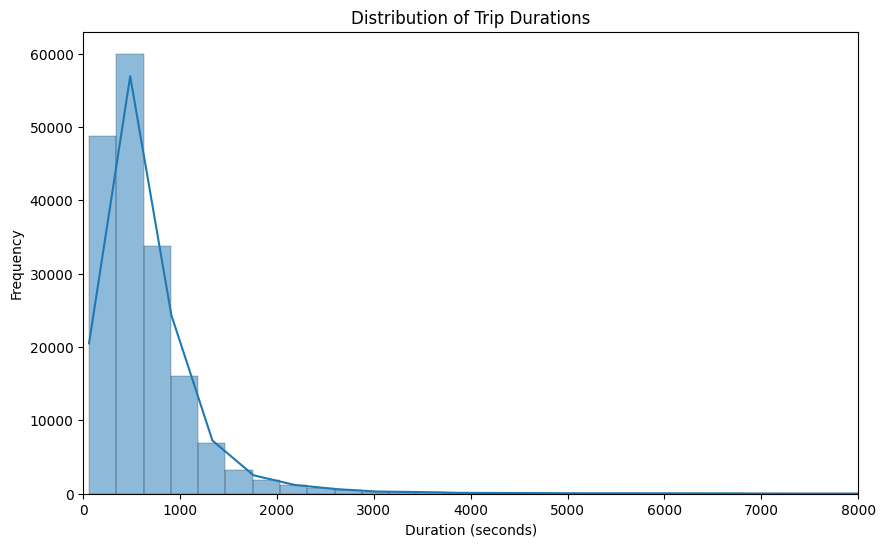

In [8]:
plt.figure(figsize=(10, 6))
sns.histplot(df['duration_sec'], kde=True, bins=300)
plt.title('Distribution of Trip Durations')
plt.xlabel('Duration (seconds)')
plt.ylabel('Frequency')
plt.xlim(0, 8000)
plt.show()

## (Visualization 2)

> You should have at least three visualizations in your presentation, but feel free to add more if you'd like!

2. Trip Duration by User Type (Boxplot)
Goal: Explore whether there are significant differences in trip duration between user types (Customer vs. Subscriber).

Comment: The boxplot can clearly show the median, quartiles, and possible outliers between the two user categories, helping to understand if one group tends to have longer trips than the other.

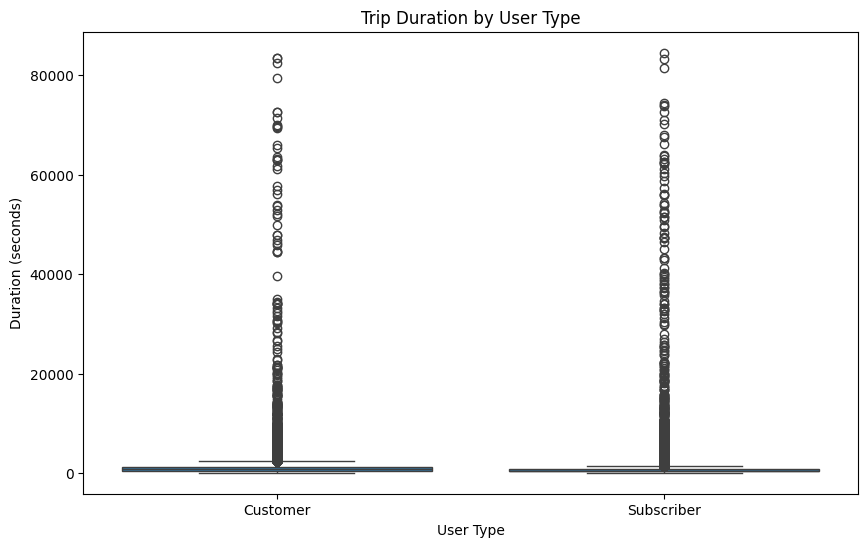

In [9]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='user_type', y='duration_sec', data=df)
plt.title('Trip Duration by User Type')
plt.xlabel('User Type')
plt.ylabel('Duration (seconds)')
plt.show()

## (Visualization 3)

> You should have at least three visualizations in your presentation, but feel free to add more if you'd like!

3. Start Stations Location (with Legend)
Goal:
The goal of this visualization is to show the geographical distribution of the top 10 most frequented start stations based on trip counts. Instead of overcrowding the scatter plot with station labels, the names of the stations will be displayed in a legend, ensuring the plot remains clean and readable.

Comment:
The scatter plot represents the longitude and latitude of the top 10 start stations, with each station marked by a unique color. The names of the stations are now presented in the legend, making it easier to identify the stations while maintaining a clean layout. This visualization helps in understanding the concentration and spread of bike stations across the city.

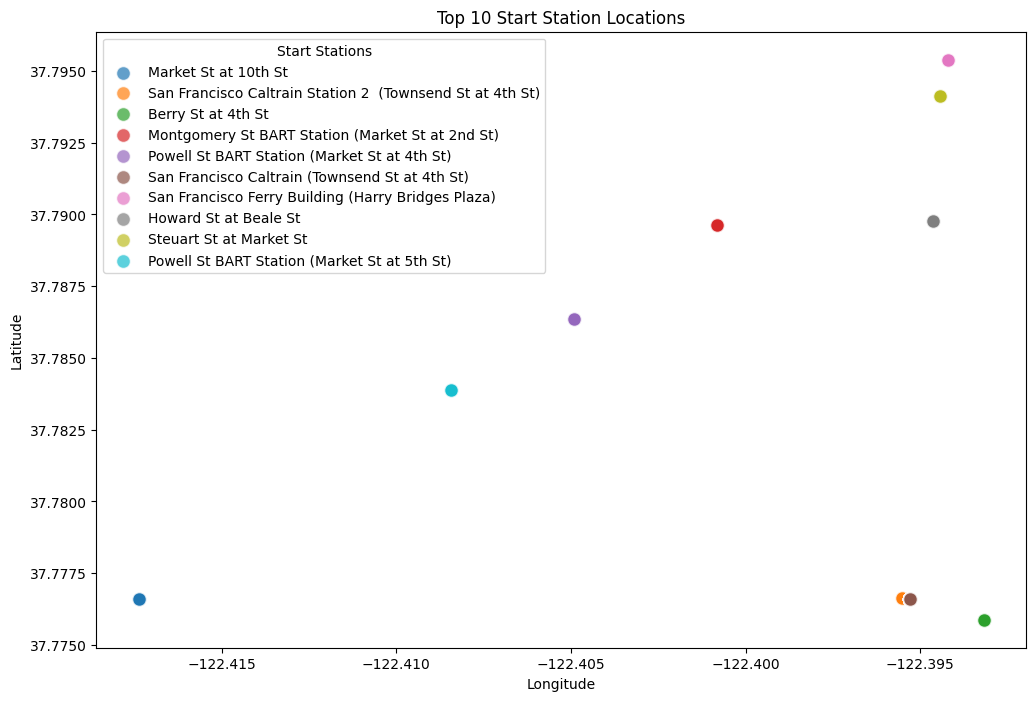

In [18]:
# Top 10 stations by trip frequency
station_counts = df['start_station_name'].value_counts().head(10)
top_stations = station_counts.index

# Filter the dataset for the top 10 stations
df_top_stations = df[df['start_station_name'].isin(top_stations)]

# Set up the plot
plt.figure(figsize=(12, 8))

# Create a scatter plot for each top station with a unique color
for station in top_stations:
    station_data = df_top_stations[df_top_stations['start_station_name'] == station]
    plt.scatter(station_data['start_station_longitude'], 
                station_data['start_station_latitude'], 
                label=station,  # Label the station for the legend
                alpha=0.7, 
                edgecolors='w', 
                s=100)  # Adjust size for better visibility

# Set titles and labels
plt.title('Top 10 Start Station Locations')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

# Add legend to the plot
plt.legend(title="Start Stations", loc='upper left', fontsize=10)

# Show the plot
plt.show()